# Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set visualization style and ignore warnings for a cleaner notebook
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# Load the Dataset

In [2]:
# Load the synthetic data we generated
data_path = '../data/freight_shipping_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (2000, 9)


# Detailed Data Inspection

In [3]:
#First 5 rows
print("--- Data Head ---")
display(df.head())

--- Data Head ---


,ShipmentID,Origin,Destination,Distance,Mode,Weather,Traffic,DepartureTime,Delay
0,S0001,Kolkata,Chennai,1591,Rail,Rain,High,13:44,102
1,S0002,Mumbai,Chennai,1886,Flight,Storm,Medium,12:59,164
2,S0003,Hyderabad,Chennai,2383,Flight,Rain,Low,04:43,65
3,S0004,Pune,Mumbai,1883,Rail,Storm,Medium,09:35,149
4,S0005,Chennai,Pune,876,Rail,Clear,Low,00:26,19


In [4]:
#Data types and missing values
print("\n--- Data Info ---")
display(df.info())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ShipmentID     2000 non-null   object
 1   Origin         2000 non-null   object
 2   Destination    2000 non-null   object
 3   Distance       2000 non-null   int64 
 4   Mode           2000 non-null   object
 5   Weather        2000 non-null   object
 6   Traffic        2000 non-null   object
 7   DepartureTime  2000 non-null   object
 8   Delay          2000 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 140.8+ KB


None

In [5]:
#Check for any null values
print("\n--- Missing Values Count ---")
display(df.isnull().sum())


--- Missing Values Count ---


ShipmentID       0
Origin           0
Destination      0
Distance         0
Mode             0
Weather          0
Traffic          0
DepartureTime    0
Delay            0
dtype: int64

In [6]:
#Statistical summary of numerical columns
print("\n--- Statistical Summary ---")
display(df.describe())


--- Statistical Summary ---


,Distance,Delay
count,2000.00000,2000.000000
mean,1423.33400,96.192000
std,716.18402,50.996446
min,146.00000,0.000000
25%,876.00000,59.000000
50%,1566.00000,89.000000
75%,2085.00000,127.000000
max,2744.00000,279.000000


In [7]:

#Check cardinality of categorical columns
print("\n--- Unique Values per Categorical Column ---")
cat_cols = ['Origin', 'Destination', 'Mode', 'Weather', 'Traffic']
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")


--- Unique Values per Categorical Column ---
Origin: 10 unique values
Destination: 10 unique values
Mode: 3 unique values
Weather: 4 unique values
Traffic: 3 unique values


# EDA - Target Variable Analysis (Delay)

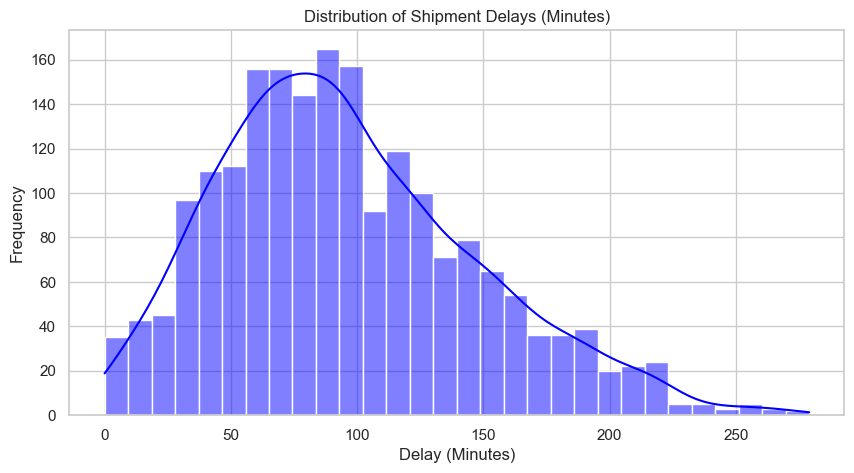

In [8]:
# Let's understand the distribution of our target variable: Delay
plt.figure(figsize=(10, 5))
sns.histplot(df['Delay'], bins=30, kde=True, color='blue')
plt.title('Distribution of Shipment Delays (Minutes)')
plt.xlabel('Delay (Minutes)')
plt.ylabel('Frequency')
plt.show()


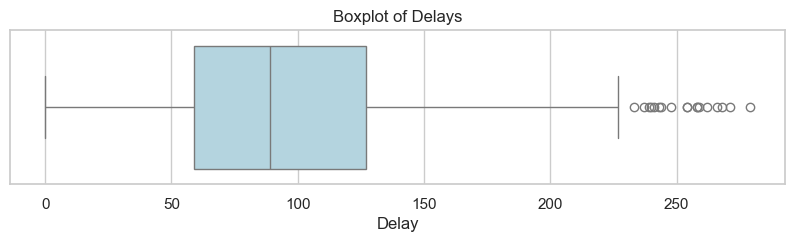

In [9]:
# Boxplot to spot outliers in delays
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Delay'], color='lightblue')
plt.title('Boxplot of Delays')
plt.show()

# EDA - Categorical Features vs. Delay

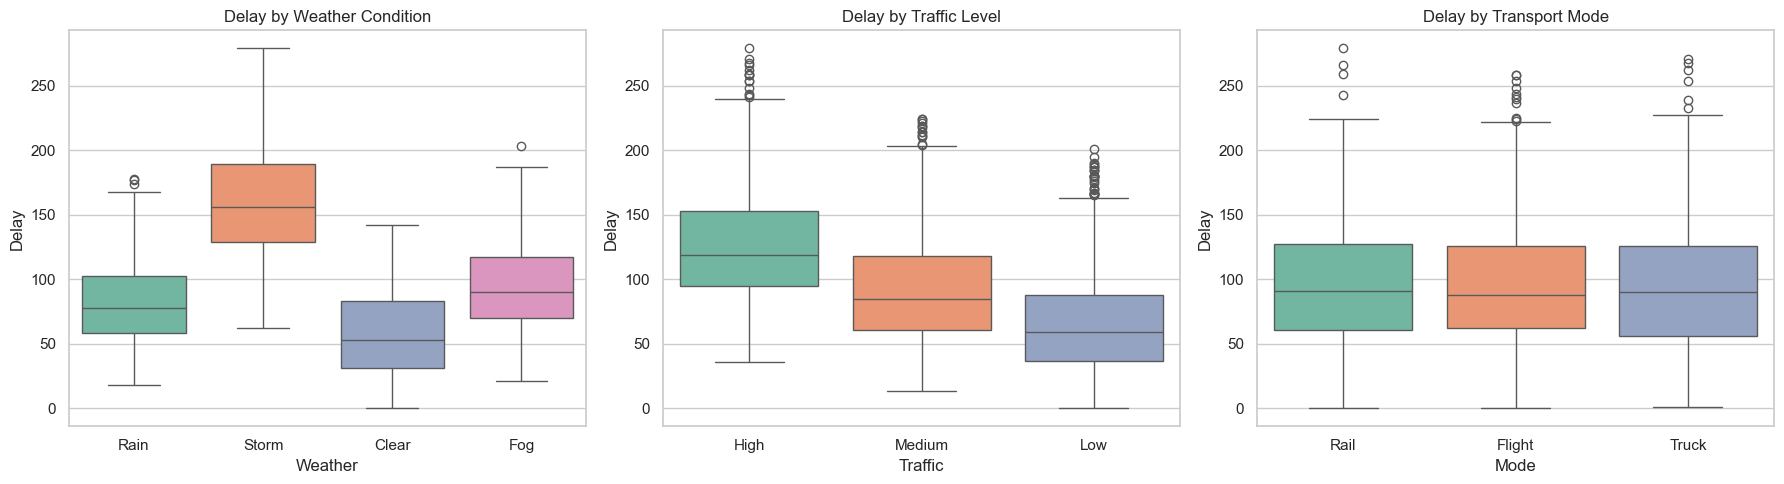

In [10]:
# How do Weather, Traffic, and Mode impact delays?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], x='Weather', y='Delay', data=df, palette='Set2')
axes[0].set_title('Delay by Weather Condition')

sns.boxplot(ax=axes[1], x='Traffic', y='Delay', data=df, palette='Set2')
axes[1].set_title('Delay by Traffic Level')

sns.boxplot(ax=axes[2], x='Mode', y='Delay', data=df, palette='Set2')
axes[2].set_title('Delay by Transport Mode')

plt.tight_layout()
plt.show()

# Feature Engineering (Preprocessing)

In [11]:
#Time Engineering: Extract Hour and define "Peak Hours"
#Assuming Peak Hours are 08:00-11:00 and 17:00-20:00
df['Hour'] = pd.to_datetime(df['DepartureTime'], format='%H:%M').dt.hour
df['Is_Peak_Hour'] = df['Hour'].apply(lambda x: 1 if (8 <= x <= 11) or (17 <= x <= 20) else 0)

#Distance Bucketing
#Categorizing distance into Short, Medium, and Long hauls
df['Distance_Bucket'] = pd.cut(
    df['Distance'], 
    bins=[0, 500, 1500, float('inf')], 
    labels=['Short', 'Medium', 'Long']
)

In [12]:
#Target Encoding for Risk Classification (For Day 1 requirements)
# On-Time (< 30), Moderate (30-120), High (> 120)
def classify_risk(delay):
    if delay < 30:
        return 'On-Time'
    elif delay <= 120:
        return 'Moderate Delay'
    else:
        return 'High Delay'

In [13]:
df['Risk_Label'] = df['Delay'].apply(classify_risk)

#Drop columns that won't be used for modeling
#ShipmentID is an identifier, DepartureTime is now captured by Hour/Is_Peak_Hour
df_model = df.drop(columns=['ShipmentID', 'DepartureTime'])

print("Feature Engineering Complete. Here is the updated dataset:")
display(df_model.head())

Feature Engineering Complete. Here is the updated dataset:


,Origin,Destination,Distance,Mode,Weather,Traffic,Delay,Hour,Is_Peak_Hour,Distance_Bucket,Risk_Label
0,Kolkata,Chennai,1591,Rail,Rain,High,102,13,0,Long,Moderate Delay
1,Mumbai,Chennai,1886,Flight,Storm,Medium,164,12,0,Long,High Delay
2,Hyderabad,Chennai,2383,Flight,Rain,Low,65,4,0,Long,Moderate Delay
3,Pune,Mumbai,1883,Rail,Storm,Medium,149,9,1,Long,High Delay
4,Chennai,Pune,876,Rail,Clear,Low,19,0,0,Medium,On-Time


# Encoding and Saving the Processed Data

In [14]:
# One-Hot Encoding for categorical variables so the ML models can read them
df_encoded = pd.get_dummies(
    df_model, 
    columns=['Origin', 'Destination', 'Mode', 'Weather', 'Traffic', 'Distance_Bucket'], 
    drop_first=True
)

# Save the preprocessed dataset for the training notebook
processed_path = '../data/processed_freight_data.csv'
df_encoded.to_csv(processed_path, index=False)

print(f"Preprocessed data saved to {processed_path}. Ready for modeling!")

Preprocessed data saved to ../data/processed_freight_data.csv. Ready for modeling!
